In [6]:
import pandas as pd

df = pd.read_csv("global_energy_mix.csv")

# Clean column names
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

print(df.columns)

Index(['country', 'region', 'source', 'share_pct', 'twh'], dtype='object')


Index(['country', 'region', 'source', 'share_pct', 'twh'], dtype='object')


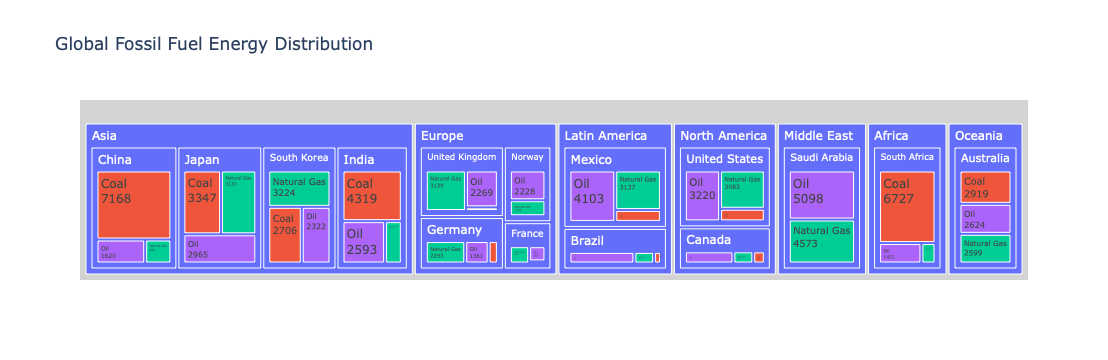


Insight:
Highest fossil fuel dependency:
region
Asia    35284.0
Name: twh, dtype: float64


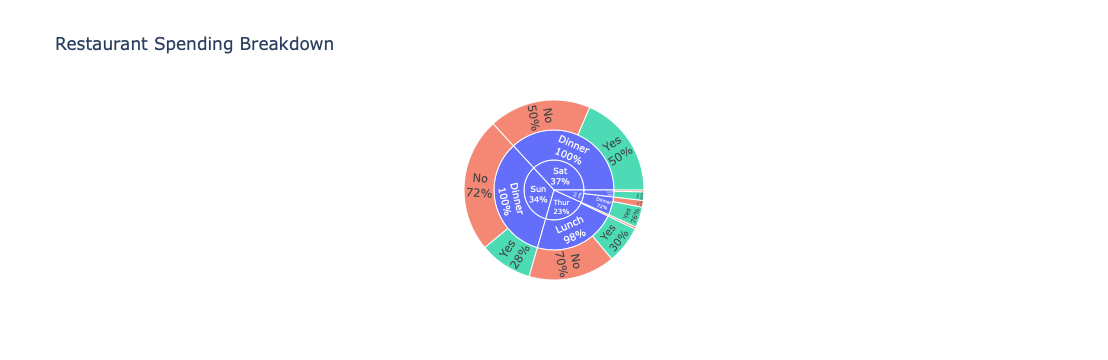


Insight:
Dinner contributes the highest restaurant revenue.


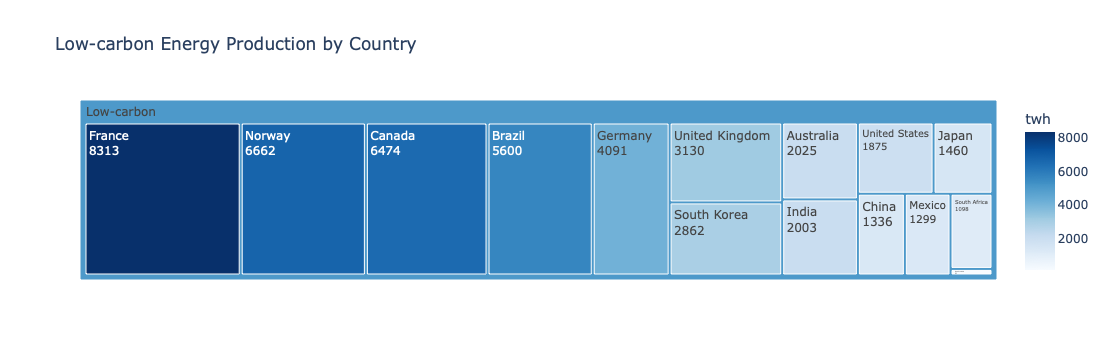

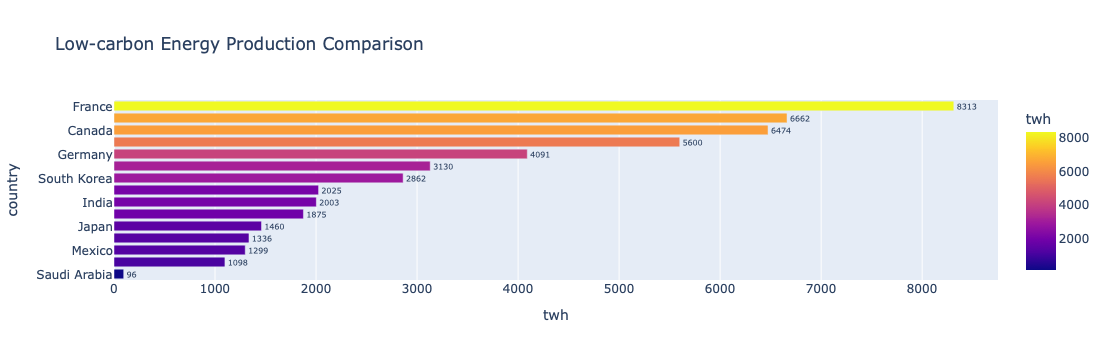


Insight:
Bar chart is better for accurate country comparison.
Treemap is better for showing proportions.


In [7]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("global_energy_mix.csv")

# Clean column names
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

print(df.columns)

# --------------------------------------------------
# Use actual column names from your CSV
# --------------------------------------------------

country_col = 'country'
region_col = 'region'
source_col = 'source'
twh_col = 'twh'

# ==================================================
# TASK 1
# ==================================================

# Fossil fuel sources
fossil_sources = ['Coal', 'Oil', 'Natural Gas']

# Filter fossil data
fossil_df = df[df[source_col].isin(fossil_sources)]

# Treemap
fig = px.treemap(
    fossil_df,
    path=[region_col, country_col, source_col],
    values=twh_col,
    color=source_col,
    title='Global Fossil Fuel Energy Distribution'
)

fig.update_traces(
    textinfo='label+value',
    root_color='lightgrey'
)

fig.show()

# Insight
top_region = (
    fossil_df.groupby(region_col)[twh_col]
    .sum()
    .sort_values(ascending=False)
)

print("\nInsight:")
print("Highest fossil fuel dependency:")
print(top_region.head(1))

# ==================================================
# TASK 2
# ==================================================

tips = px.data.tips()

tips_summary = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

fig = px.sunburst(
    tips_summary,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    title='Restaurant Spending Breakdown'
)

fig.update_traces(
    textinfo='label+percent parent',
    root_color='lightgrey'
)

fig.show()

print("\nInsight:")
print("Dinner contributes the highest restaurant revenue.")

# ==================================================
# TASK 3
# ==================================================

# Low-carbon sources
low_carbon_sources = ['Hydro', 'Wind', 'Solar', 'Nuclear']

# Filter low-carbon data
low_carbon_df = df[df[source_col].isin(low_carbon_sources)]

# Aggregate by country
country_energy = (
    low_carbon_df.groupby(country_col)[twh_col]
    .sum()
    .reset_index()
    .sort_values(by=twh_col, ascending=False)
)

# ---------------- TREEMAP ----------------

country_energy['All'] = 'Low-carbon'

treemap_fig = px.treemap(
    country_energy,
    path=['All', country_col],
    values=twh_col,
    color=twh_col,
    color_continuous_scale='Blues',
    title='Low-carbon Energy Production by Country'
)

treemap_fig.update_traces(
    textinfo='label+value',
    root_color='lightgrey'
)

treemap_fig.show()

# ---------------- BAR CHART ----------------

bar_fig = px.bar(
    country_energy.sort_values(twh_col),
    x=twh_col,
    y=country_col,
    orientation='h',
    color=twh_col,
    text=twh_col,
    title='Low-carbon Energy Production Comparison'
)

bar_fig.update_traces(
    textposition='outside'
)

bar_fig.show()

# Insight
print("\nInsight:")
print("Bar chart is better for accurate country comparison.")
print("Treemap is better for showing proportions.")